In [1]:
library(Seurat)

Attaching SeuratObject

Seurat v4 was just loaded with SeuratObject v5; disabling v5 assays and
validation routines, and ensuring assays work in strict v3/v4
compatibility mode



In [2]:
input_files <- c('/mnt/cold1/snaketree/prj/scRNA/dataset/rCASC_Ire_cetuxi/CRC0322_NT_1_3000_dir/filtered_annotated_CRC0322_NT_1_3000.tsv',
                 '/mnt/cold1/snaketree/prj/scRNA/dataset/rCASC_Ire_cetuxi/CRC0327_NT_2_dir/filtered_annotated_CRC0327_NT_2.tsv', 
                 '/mnt/cold1/snaketree/prj/scRNA/dataset/rCASC_longer/CRC0542_NT72h_1_dir/filtered_annotated_CRC0542_NT72h_1.tsv')
                 
samples <- c('CRC0322', 'CRC0327', 'CRC0542')

#filtergenes <- ''
#or 
filtergenes <- 'Graphs/grafo_filtrato_undirect_small.csv'

if (filtergenes != '') {
    nfeatures <- 949
    npc <- 300
    resolution <- 0.4 # even with 0.8 we do not get a better cluster 4 # big jump 0.1 - 0.2 ?
    # 0.12 with 20 npc for 5 clusters
    # 0.3 for 200 for 4 clusters
} else {
    nfeatures <- 1000
    npc <- 20
    resolution <- 0.1
}

# test 2 extreme res + contingency 
# test scale cycle

In [3]:
genes <- read.csv(filtergenes)
keepg <- unique(c(genes$source))
length(keepg)

[1] 949

In [4]:
# create seurat objects and integrates
input_files_l <- unlist(strsplit(input_files, ','))

createSeurat <- function(file, genes) {
  df <- read.table(gzfile(file), sep=',', header=TRUE, row.names=1)
  keep <- sapply(rownames(df), function(x) {g <- strsplit(x, ':')[1][[1]]; g[2] %in% genes})
  df <- df[keep,]
  res <- CreateSeuratObject(df)
  return(res)
}

data_list <- lapply(input_files_l, createSeurat, keepg)

data_list <- lapply(X = data_list, FUN = function(x) {
    x <- NormalizeData(x)
    x <- ScaleData(x)
    x <- FindVariableFeatures(x, selection.method = "vst", nfeatures = nfeatures)
    
})

features <- SelectIntegrationFeatures(object.list = data_list, nfeatures= nfeatures)
anchors <- FindIntegrationAnchors(object.list = data_list, anchor.features = features, dims=1:npc)# paneth split in two clusters in this way
sdata <- IntegrateData(anchorset = anchors, dims=1:npc) 
DefaultAssay(sdata) <- "integrated"



Warning message:
“The `slot` argument of `SetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Centering and scaling data matrix

Centering and scaling data matrix

Centering and scaling data matrix

Warning message in CheckDuplicateCellNames(object.list = object.list):
“Some cell names are duplicated across objects provided. Renaming to enforce unique cell names.”
Scaling features for provided objects

Finding all pairwise anchors

Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning messag

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


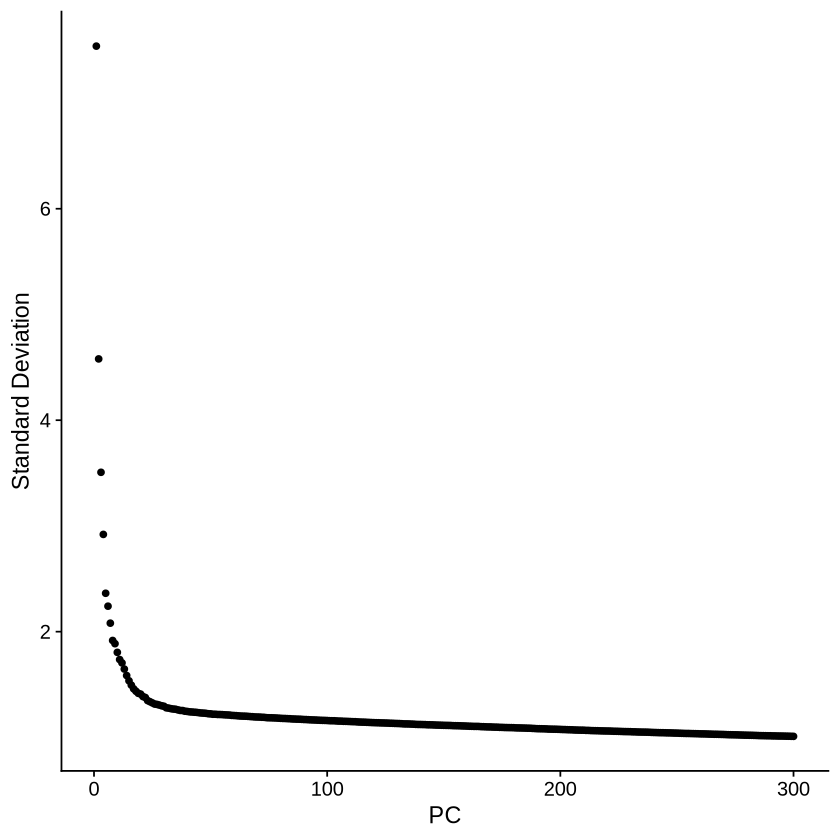

In [5]:
# Scale PCA UMAP on integrated
sdata <- ScaleData(sdata, verbose = FALSE)
sdata <- RunPCA(sdata, verbose = FALSE, npcs = npc)

ElbowPlot(sdata, ndims=npc)

sdata <- RunUMAP(sdata, reduction = "pca", dims = 1:npc, verbose=F)
sdata <- FindNeighbors(sdata, reduction = "pca", dims = 1:npc, verbose=F)

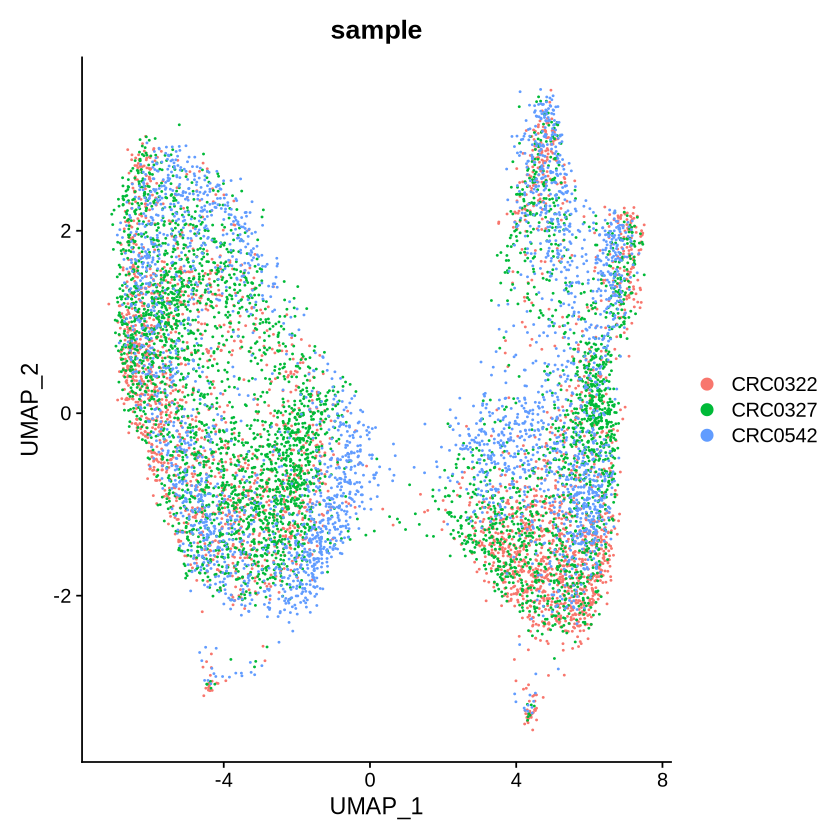

In [6]:
#UMAP with samples
cells <- colnames(sdata)

samples_n <- sapply(strsplit(cells, "_"), function(x){x[[2]]})
sdata$sample <- samples[as.numeric(samples_n)]
DimPlot(sdata, reduction = "umap", group.by='sample')


Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 10050
Number of edges: 4275946

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8090
Number of communities: 4
Elapsed time: 11 seconds


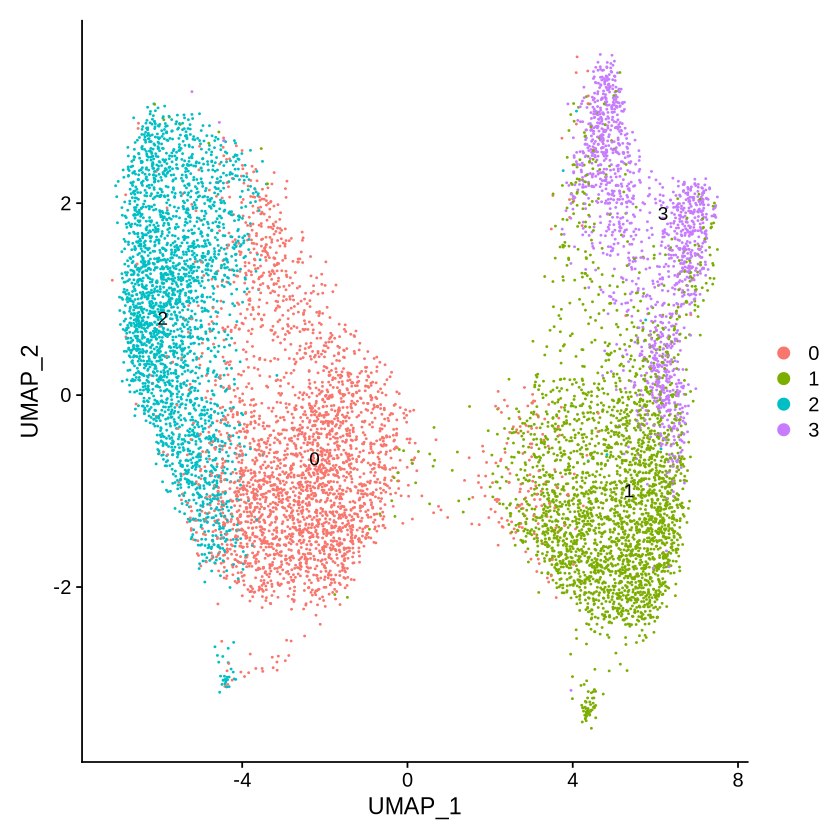

In [7]:
# UMAP with clusters
DefaultAssay(sdata) <- "integrated"

sdata <- FindClusters(sdata, resolution = resolution)
DimPlot(sdata, reduction = "umap", label = TRUE, repel = TRUE)

In [8]:
filesp <- c('/mnt/cold1/snaketree/prj/scRNA/dataset/KMeans_2/kmeans/CRC0322_NT_1_3000/CRC0322_NT_1_3000_kmeans_2comp.csv',
            '/mnt/cold1/snaketree/prj/scRNA/dataset/KMeans_2/kmeans/CRC0327_NT_2/CRC0327_NT_2_kmeans_2comp.csv',
            '/mnt/cold1/snaketree/prj/scRNA/dataset/KMeans_2/kmeans/CRC0542_NT72h_1/CRC0542_NT72h_1_kmeans_2comp.csv')

alld <- data.frame()

for (i in seq(1, length(filesp))) {
    data <- read.csv(filesp[i], sep=',', header=TRUE, row.names=1)
    data$cellname <- paste0(rownames(data), '_', i)
    data[data$isPaneth == "filtered", 'isPaneth'] <- 'nPaneth'            
    alld <- rbind(alld, data)
}



[1] TRUE

         
             0    1    2    3
  nPaneth 2984 2844 2738  853
  Paneth     3   52   10  566

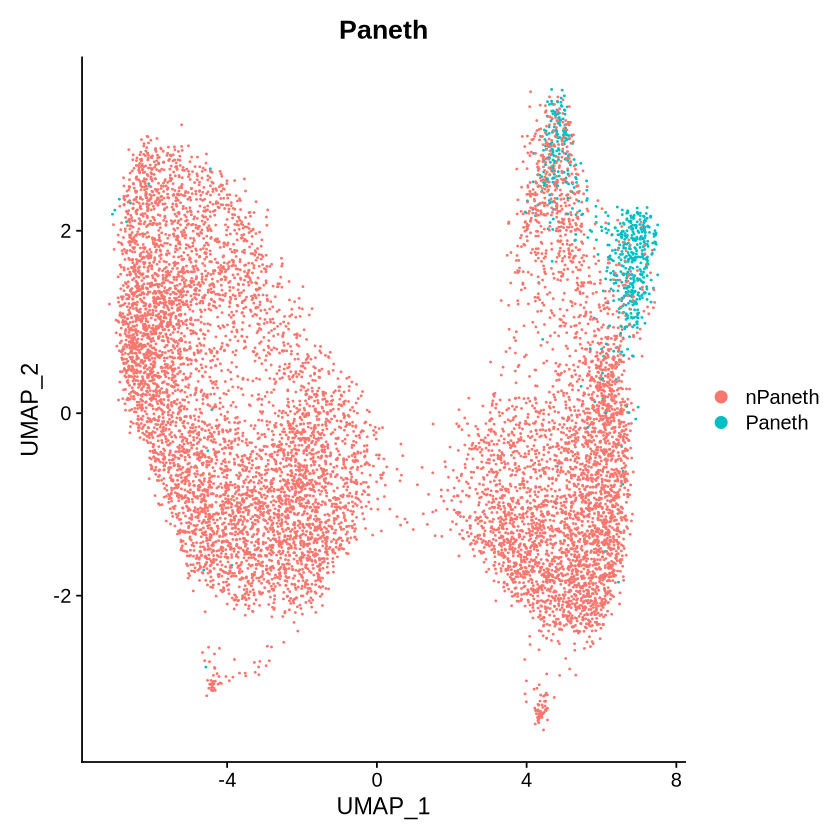

In [9]:
wo <- colnames(sdata)

alld <- alld[match(wo, alld$cellname),]
all(wo == alld$cellname)
sdata$Paneth <- alld$isPaneth
DimPlot(sdata, reduction = "umap", group.by='Paneth')
table(sdata$Paneth, sdata$seurat_clusters)


In [10]:
DefaultAssay(sdata) <- "RNA"

df <- data.frame(row.names=names(sdata$orig.ident), sample=sdata$sample, cluster=sdata$seurat_clusters)

n_cl <- length(unique(df$cluster))
deg <- list()
for (i in seq(0,(n_cl-1))) {
	cl <- as.data.frame(FindConservedMarkers(sdata, ident.1 = i, verbose = FALSE, grouping.var="sample"))
    deg[[i+1]] <- cl[cl$max_pval < 0.05,]
}


Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


In [11]:
for (i in seq(0,(n_cl-1))) {
    print(paste0('cluster ', i))
    d <- deg[[i+1]]
    d <- d[order(-d$CRC0322_avg_log2FC),]
    print(head(d[, grepl('log2FC', colnames(d))], n=10))
    print(head(d[, grepl('adj', colnames(d))], n=10))
}

[1] "cluster 0"
                        CRC0322_avg_log2FC CRC0542_avg_log2FC
ENSG00000101412:E2F1              1.984606           1.666851
ENSG00000112118:MCM3              1.621626           1.526337
ENSG00000076003:MCM6              1.543436           1.358684
ENSG00000131153:GINS2             1.515197           1.545738
ENSG00000104738:MCM4              1.501789           1.489854
ENSG00000168496:FEN1              1.499651           1.229274
ENSG00000132646:PCNA              1.435857           1.393603
ENSG00000119969:HELLS             1.300773           1.459121
ENSG00000189057:FAM111B           1.284717           1.527473
ENSG00000100297:MCM5              1.269650           1.306677
                        CRC0327_avg_log2FC
ENSG00000101412:E2F1              2.050815
ENSG00000112118:MCM3              1.213828
ENSG00000076003:MCM6              1.718240
ENSG00000131153:GINS2             1.642364
ENSG00000104738:MCM4              1.384541
ENSG00000168496:FEN1              1.237771
E

In [12]:
write.table(df, file="/mnt/cold1/snaketree/prj/scRNA/dataset/Graph_NN/notebook/seurat_v4_integration_trainWT_graphgenes_morePC.tsv", sep="\t", quote=F, row.names=T)

In [13]:
cl_tot <- read.table("/mnt/cold1/snaketree/prj/scRNA/dataset/Graph_NN/notebook/seurat_v4_integration_trainWT_graphgenes_lessPC.tsv", sep= "\t", row.names=1, header=T)
head(cl_tot)
head(df)
colnames(cl_tot) <- paste0(colnames(cl_tot), '_tot')
df <- data.frame(row.names=names(sdata$orig.ident), sample=sdata$sample, cluster=sdata$seurat_clusters)


,sample,cluster
,<chr>,<int>
CATGGATGTGTGTGGA.1_1,CRC0322,0
TAGAGTCAGTACTGTC.1_1,CRC0322,2
AGGTAGGAGATGCAGC.1_1,CRC0322,1
CATGCCTAGGTGCCTC.1_1,CRC0322,2
TGAATGCAGAACCGCA.1_1,CRC0322,0
CAAAGAAGTAAGATAC.1_1,CRC0322,0


,sample,cluster
,<chr>,<fct>
CATGGATGTGTGTGGA.1_1,CRC0322,1
TAGAGTCAGTACTGTC.1_1,CRC0322,2
AGGTAGGAGATGCAGC.1_1,CRC0322,0
CATGCCTAGGTGCCTC.1_1,CRC0322,2
TGAATGCAGAACCGCA.1_1,CRC0322,1
CAAAGAAGTAAGATAC.1_1,CRC0322,1


In [14]:
m <- merge(df, cl_tot, by="row.names")
dim(m)
dim(df)
dim(cl_tot)
head(m)

[1] 10050     5

[1] 10050     2

[1] 10050     2

,Row.names,sample,cluster,sample_tot,cluster_tot
,<I<chr>>,<chr>,<fct>,<chr>,<int>
1,AAACCCAAGATTGTGA.1_3,CRC0542,0,CRC0542,0
2,AAACCCAAGCCTATCA.1_1,CRC0322,0,CRC0322,2
3,AAACCCAAGCTCGACC.1_1,CRC0322,3,CRC0322,3
4,AAACCCAAGGAATTAC.1_3,CRC0542,1,CRC0542,0
5,AAACCCAAGGACAGCT.1_2,CRC0327,0,CRC0327,1
6,AAACCCAAGGCACGAT.1_1,CRC0322,2,CRC0322,1


In [15]:
table(m$cluster, m$cluster_tot)

   
       0    1    2    3    4
  0  319 2020  592    0   56
  1 2659  122   83   19   13
  2    4  922 1809    0   13
  3  782   17   19  601    0

In [16]:
rowSums(table(m$cluster, m$cluster_tot))

0    1    2    3 
2987 2896 2748 1419

In [17]:
sapply(deg, nrow)

[1] 163 189 129 261

In [18]:
sapply(deg, function(x) {xx <- x[, grepl('avg_log', colnames(x))]; table(apply(xx, 1, function(x) {all(x > 0)} )) })

FALSE,50,165,29,165
TRUE,113,24,100,96


Warning message:
“The `slot` argument of `FetchData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


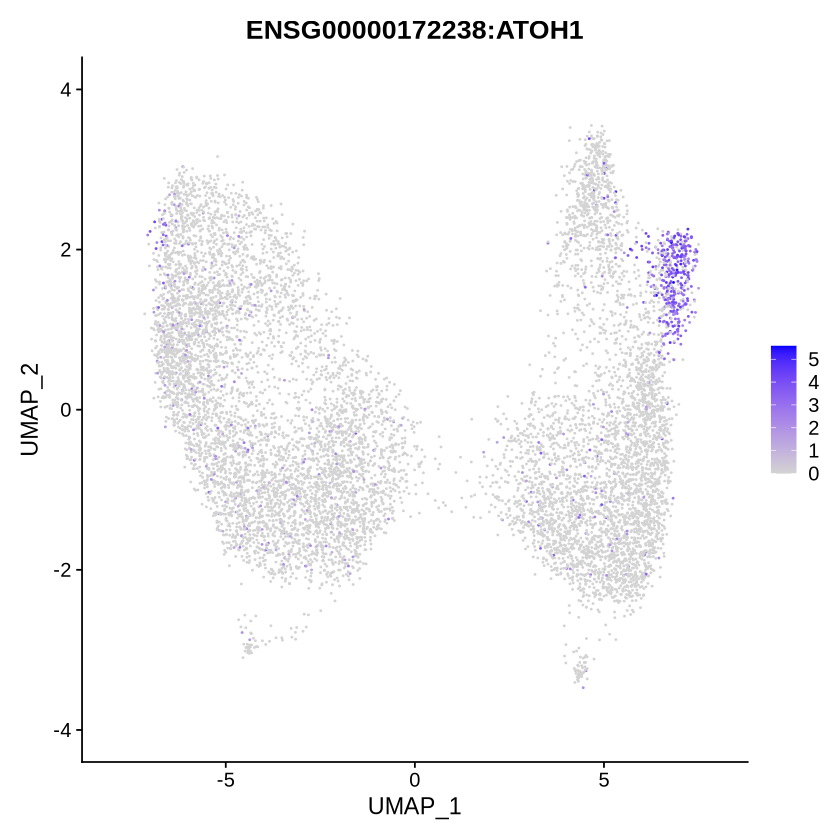

In [19]:
FeaturePlot(sdata, features = 'ENSG00000172238:ATOH1')

In [20]:
filesp <- c('/mnt/cold1/snaketree/prj/scRNA/dataset/rCASC_Ire_cetuxi/CRC0322_NT_1_3000_dir/filtered_annotated_CRC0322_NT_1_3000_cellCycle.tsv',
            '/mnt/cold1/snaketree/prj/scRNA/dataset/rCASC_Ire_cetuxi/CRC0327_NT_2_dir/filtered_annotated_CRC0327_NT_2_cellCycle.tsv',
            '/mnt/cold1/snaketree/prj/scRNA/dataset/rCASC_longer/CRC0542_NT72h_1_dir/filtered_annotated_CRC0542_NT72h_1_cellCycle.tsv')


alld <- data.frame()
cells <- colnames(sdata)

for (i in seq(1, length(filesp))) {
    data <- read.csv(filesp[i], sep=',', header=FALSE, row.names=1)
    colnames(data) <- c('cycle')
    data$cellname <- paste0(rownames(data), '_', i)
    alld <- rbind(alld, data)
}


[1] TRUE

     
         0    1    2    3
  G1   489 2615   22 1176
  G2M  330   58 2432  146
  S   2168  223  294   97

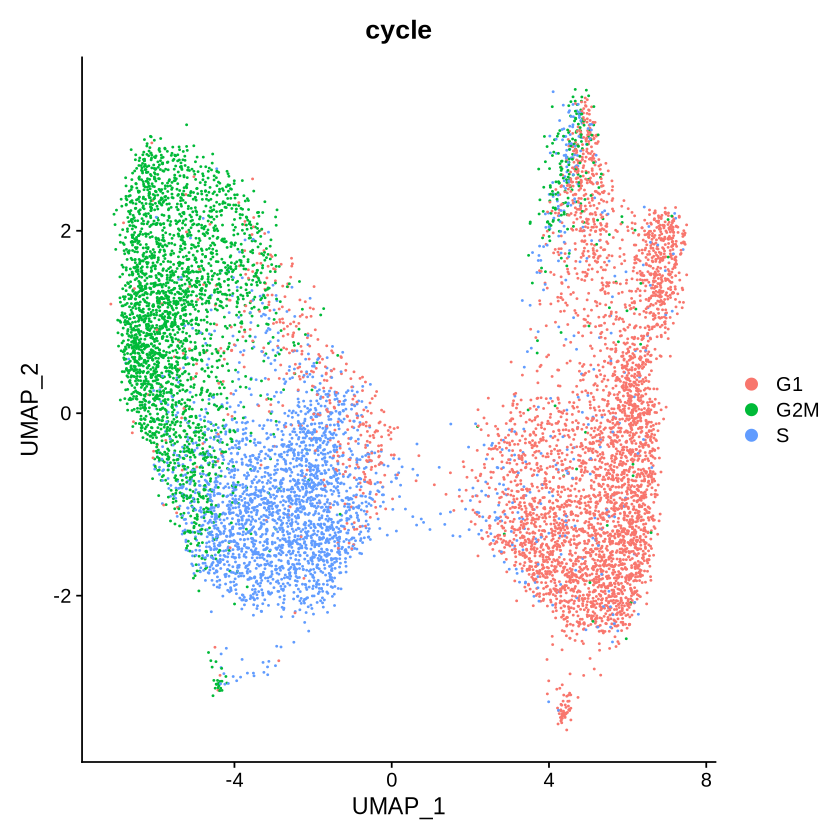

In [21]:
wo <- colnames(sdata)

alld <- alld[match(wo, alld$cellname),]
all(wo == alld$cellname)
sdata$cycle <- alld$cycle
DimPlot(sdata, reduction = "umap", group.by='cycle')
table(sdata$cycle, sdata$seurat_clusters)

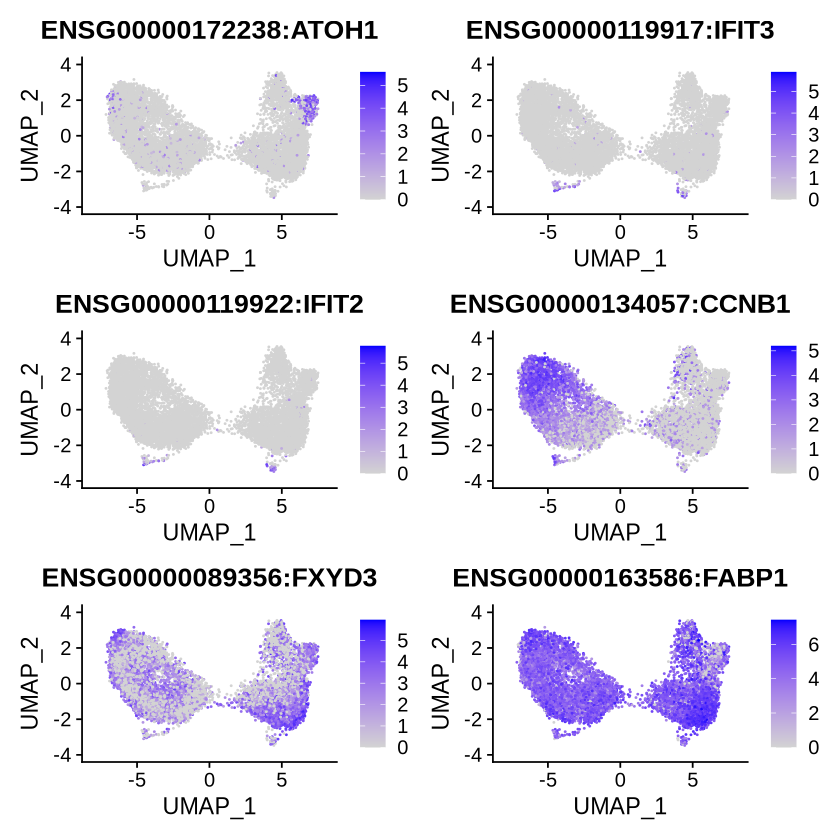

In [23]:
FeaturePlot(sdata, features = c('ENSG00000172238:ATOH1', 'ENSG00000119917:IFIT3', 'ENSG00000119922:IFIT2', 'ENSG00000134057:CCNB1', 'ENSG00000089356:FXYD3', 'ENSG00000163586:FABP1'))